# 06 - Robot Arm Reference Tracking Control


### Setup
Install dependencies in Colab and define paths for checkpoint, dataset, XML model, and outputs.


In [ ]:
from pathlib import Path
import os
import random
import subprocess
import sys

import numpy as np
import torch

# If the repo is not present in /content, set REPO_URL to your GitHub repo and rerun.
REPO_URL = "https://github.com/<your-org>/score-manifold-optimization.git"
REPO_DIR = Path("/content/score-manifold-optimization")

if not (REPO_DIR / "pyproject.toml").exists():
    if "<" in REPO_URL:
        raise RuntimeError(
            "Repo not found at /content/score-manifold-optimization. "
            "Please set REPO_URL to your repository URL or clone manually."
        )
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-e", ".[mujoco]"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "imageio[ffmpeg]"], check=True)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_DIR = REPO_DIR / "outputs/robot_arm_train_demo"
DATASET_PATH = REPO_DIR / "data/robot_arm_T100_n20000.pt"
XML_PATH = REPO_DIR / "examples/colab/robot_arm_2dof.xml"
OUTPUT_DIR = REPO_DIR / "outputs/robot_arm_control_demo"

print(f"Repo: {REPO_DIR}")
print(f"Device: {DEVICE}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Dataset path: {DATASET_PATH}")
print(f"XML path: {XML_PATH}")
print(f"Output dir: {OUTPUT_DIR}")


### Local Setup (Alternative)
Use this local setup when the repo is already available on your machine.


In [1]:
from pathlib import Path
import os
import random

import numpy as np
import torch

start = Path.cwd().resolve()
REPO_DIR = next((p for p in [start, *start.parents] if (p / "pyproject.toml").exists()), None)
if REPO_DIR is None:
    raise RuntimeError("Could not find repo root (missing pyproject.toml in parent dirs).")

os.chdir(REPO_DIR)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT_DIR = REPO_DIR / "outputs/robot_arm_train_demo"
DATASET_PATH = REPO_DIR / "data/robot_arm_T100_n20000.pt"
XML_PATH = REPO_DIR / "examples/colab/robot_arm_2dof.xml"
OUTPUT_DIR = REPO_DIR / "outputs/robot_arm_control_demo"

print(f"Repo root: {REPO_DIR}")
print(f"Device: {DEVICE}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")
print(f"Dataset path: {DATASET_PATH}")
print(f"XML path: {XML_PATH}")
print(f"Output dir: {OUTPUT_DIR}")

# Install once from terminal (repo root):
# pip install -e .[mujoco]
# pip install imageio[ffmpeg]


Repo root: /Users/andrei/Documents/score-manifold-optimization
Device: cpu
Checkpoint dir: /Users/andrei/Documents/score-manifold-optimization/outputs/robot_arm_train_demo
Dataset path: /Users/andrei/Documents/score-manifold-optimization/data/robot_arm_T100_n20000.pt
XML path: /Users/andrei/Documents/score-manifold-optimization/examples/colab/robot_arm_2dof.xml
Output dir: /Users/andrei/Documents/score-manifold-optimization/outputs/robot_arm_control_demo


### Load Model + Data Context
Load the pretrained score model and trajectory dataset, then confirm the dynamics constraint type.


In [2]:
from diffusion.control import DynamicsConstraint
from diffusion.utils.checkpoint_utils import load_pretrained_score_context

context = load_pretrained_score_context(
    checkpoint_dir=CHECKPOINT_DIR,
    dataset_path_override=DATASET_PATH,
    device=DEVICE,
    require_trajectory_data=True,
)

train_data = context.train_data
constraint = context.constraint
model = context.model
diffusion = context.diffusion

if not isinstance(constraint, DynamicsConstraint):
    raise TypeError(f"Expected DynamicsConstraint, got {type(constraint)}")

print(f"Train data shape: {tuple(train_data.shape)}")
print(f"Constraint: {constraint.__class__.__name__}")
print(f"Input dim: {constraint.system.get_input_dim()}, output dim: {constraint.system.get_output_dim()}")


Loading canonical format (model.pth + checkpoint_data.pt + config.yaml)
Progress: epoch=49999, global_step=500000
Loading dataset from /Users/andrei/Documents/score-manifold-optimization/data/robot_arm_T100_n20000.pt...
  Successfully loaded dataset:
    Train: torch.Size([20000, 100, 6])
    Test: torch.Size([2000, 100, 6])
    Val: torch.Size([1000, 100, 6])
Train data shape: (20000, 100, 6)
Constraint: DynamicsConstraint
Input dim: 2, output dim: 4


### Build Joint-Position Reference and Initial Trajectory
Create a joint-position reference (only q1, q2), then pick the best initial trajectory from training data.


Reference shape: (1, 100, 2)
Best initial index: 484


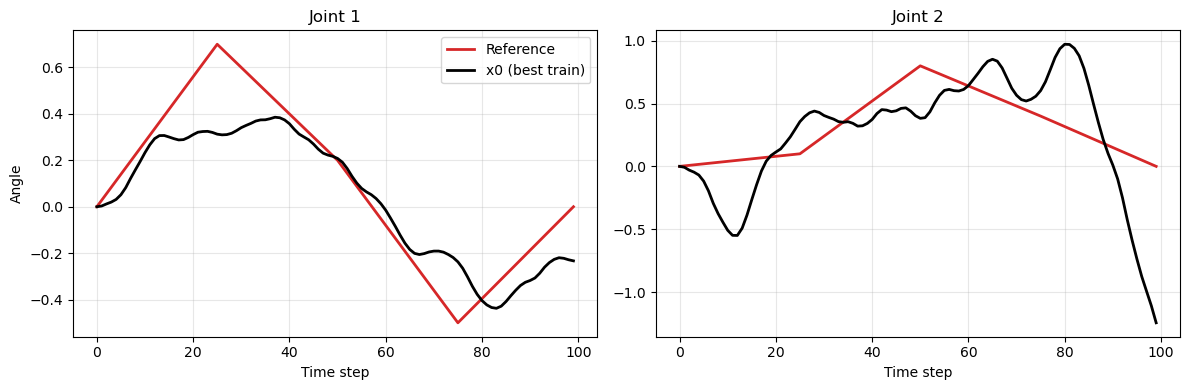

In [10]:
from diffusion.control import build_reference_tracking_objective
import matplotlib.pyplot as plt

horizon = constraint.horizon

device = train_data.device
dtype = train_data.dtype

# Piecewise-linear waypoints for joint positions (q1, q2)
q_knots = torch.tensor(
    [
        [0.0, 0.0],
        [0.7, 0.1],
        [0.2, 0.8],
        [-0.5, 0.4],
        [0.0, 0.0],
    ],
    device=device,
    dtype=dtype,
)

# Knot indices along the horizon
t_knots = [0, horizon // 4, horizon // 2, 3 * horizon // 4, horizon - 1]

q_ref = torch.empty(horizon, 2, device=device, dtype=dtype)
for k in range(len(t_knots) - 1):
    i0, i1 = t_knots[k], t_knots[k + 1]
    alpha = torch.linspace(0.0, 1.0, i1 - i0 + 1, device=device, dtype=dtype).unsqueeze(-1)
    q_ref[i0 : i1 + 1] = (1.0 - alpha) * q_knots[k] + alpha * q_knots[k + 1]

reference = q_ref.unsqueeze(0)  # shape (1, horizon, 2)

u_dim = constraint.input_dim
slice_spec = [u_dim + 0, u_dim + 1]
loss_type = "L1"

objective_fn = build_reference_tracking_objective(
    reference_trajectory=reference,
    slice_spec=slice_spec,
    loss_type=loss_type,
)

with torch.no_grad():
    objective_values = objective_fn(train_data)
    best_idx = int(torch.argmin(objective_values).item())

x0 = train_data[best_idx : best_idx + 1].detach().clone()

print(f"Reference shape: {tuple(reference.shape)}")
print(f"Best initial index: {best_idx}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for j in range(2):
    axes[j].plot(reference[0, :, j].detach().cpu(), color="tab:red", linewidth=2, label="Reference")
    axes[j].plot(x0[0, :, slice_spec[j]].detach().cpu(), color="k", linewidth=2, label="x0 (best train)")
    axes[j].set_title(f"Joint {j+1}")
    axes[j].set_xlabel("Time step")
    axes[j].grid(alpha=0.3)
axes[0].set_ylabel("Angle")
axes[0].legend()
plt.tight_layout()
plt.show()


### Run Tracking (DRGD)
Run score-based reference tracking and plot objective and simulation MSE convergence.


Tracking complete.


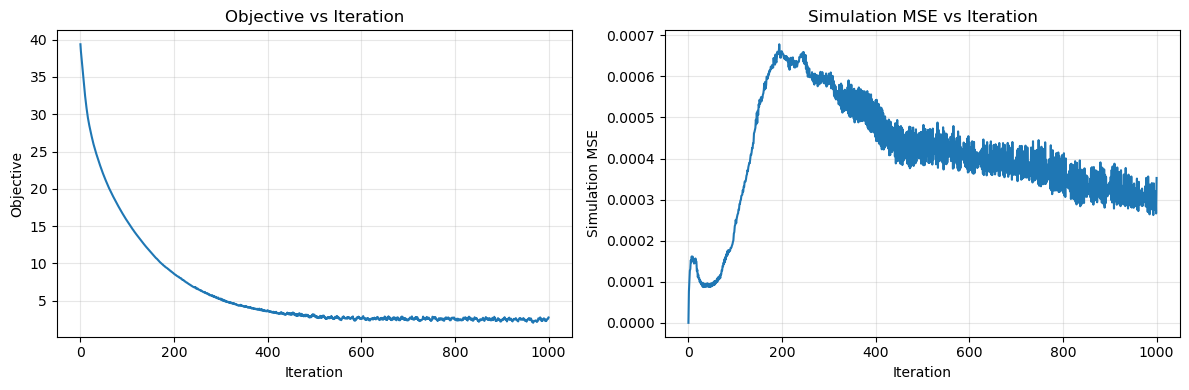

In [19]:
from diffusion.control import run_reference_tracking
from diffusion.optimization import RiemannianConfig, ScoreTangentConfig, build_score_projector
import matplotlib.pyplot as plt

projector = build_score_projector(
    score_model=model,
    diffusion=diffusion,
    score_time=0.25,
    data_dims=train_data.shape[1:],
    n_proj=1,
    tangent_cfg=ScoreTangentConfig(method="jvp"),
)

cfg = RiemannianConfig(
    step_size=3e-2,
    n_steps=1000,
    tangent_mode="projector",
)


def log_fn(x):
    u, y = constraint.split_input_output(x)
    x0_state = y[:, 0]
    y_sim = constraint.system.simulate_out(x0_state, u)
    return {"simulation_mse": float((y_sim - y).pow(2).mean().detach().item())}

tracking = run_reference_tracking(
    reference_trajectory=reference,
    slice_spec=slice_spec,
    projector=projector,
    cfg=cfg,
    x0=x0,
    loss_type=loss_type,
    log_fn=log_fn,
)

print("Tracking complete.")

iterations = range(len(tracking["objective_history"]))
simulation_mse_history = [
    float(v.get("simulation_mse", float("nan"))) if isinstance(v, dict) else float("nan")
    for v in tracking["log_output"]
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(iterations, tracking["objective_history"])
axes[0].set_title("Objective vs Iteration")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Objective")
axes[0].grid(alpha=0.3)

axes[1].plot(iterations, simulation_mse_history)
axes[1].set_title("Simulation MSE vs Iteration")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Simulation MSE")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Plot Optimized vs Simulated Trajectories
Compare reference, optimized, simulated, and best-training baselines for the two joint positions.


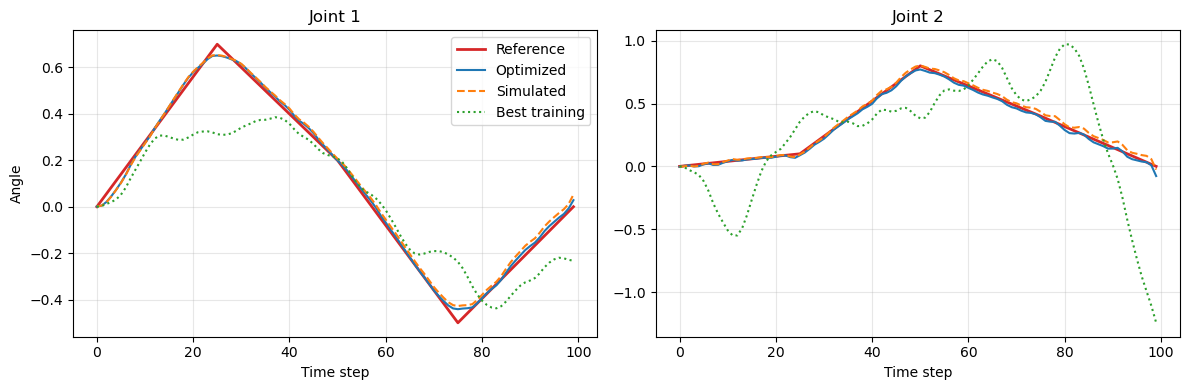

In [20]:
import matplotlib.pyplot as plt
u_opt, y_opt = constraint.split_input_output(tracking["result"].trajectory[-1])
x0_state = y_opt[:, 0]

with torch.no_grad():
    y_sim = constraint.system.simulate_out(x0_state, u_opt)

best_pair = train_data[best_idx : best_idx + 1]
_, y_best = constraint.split_input_output(best_pair)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
time_axis = torch.arange(y_opt.shape[1]).cpu()

for j in range(2):
    axes[j].plot(time_axis, reference[0, :, j].detach().cpu(), color="tab:red", linewidth=2, label="Reference")
    axes[j].plot(time_axis, y_opt[0, :, j].detach().cpu(), color="tab:blue", label="Optimized")
    axes[j].plot(time_axis, y_sim[0, :, j].detach().cpu(), color="tab:orange", linestyle="--", label="Simulated")
    axes[j].plot(time_axis, y_best[0, :, j].detach().cpu(), color="tab:green", linestyle=":", label="Best training")
    axes[j].set_title(f"Joint {j+1}")
    axes[j].set_xlabel("Time step")
    axes[j].grid(alpha=0.3)

axes[0].set_ylabel("Angle")
axes[0].legend()
plt.tight_layout()
plt.show()


### Animate Optimized and Simulated Rollouts (MP4)
Render both rollouts using MuJoCo and preview them inline as MP4 videos.


In [31]:
import imageio.v2 as imageio
import mujoco
import numpy as np
from IPython.display import Video, display

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
model_mj = mujoco.MjModel.from_xml_path(str(XML_PATH))
link1_len = 0.5
link2_len = 0.5


def reference_fk_points(q_ref_t: np.ndarray) -> np.ndarray:
    q1, q2 = float(q_ref_t[0]), float(q_ref_t[1])
    base = np.array([0.0, 0.0, 0.0], dtype=np.float64)
    elbow = np.array([link1_len * np.cos(q1), link1_len * np.sin(q1), 0.0], dtype=np.float64)
    tip = elbow + np.array([link2_len * np.cos(q1 + q2), link2_len * np.sin(q1 + q2), 0.0], dtype=np.float64)
    return np.stack([base, elbow, tip], axis=0)


def add_reference_ghost(scene, q_ref_t: np.ndarray) -> None:
    points = reference_fk_points(q_ref_t)
    base, elbow, tip = points[0], points[1], points[2]

    red = np.array([1.0, 0.1, 0.1, 0.45], dtype=np.float32)
    mat_flat = np.eye(3, dtype=np.float64).reshape(-1)

    def add_capsule(p0: np.ndarray, p1: np.ndarray, radius: float = 0.018) -> None:
        if scene.ngeom >= scene.maxgeom:
            return
        geom = scene.geoms[scene.ngeom]
        mujoco.mjv_initGeom(
            geom,
            mujoco.mjtGeom.mjGEOM_CAPSULE,
            np.array([radius, radius, radius], dtype=np.float64),
            np.zeros(3, dtype=np.float64),
            mat_flat,
            red,
        )
        mujoco.mjv_connector(geom, mujoco.mjtGeom.mjGEOM_CAPSULE, radius, p0, p1)
        scene.ngeom += 1

    def add_sphere(p: np.ndarray, radius: float = 0.028) -> None:
        if scene.ngeom >= scene.maxgeom:
            return
        geom = scene.geoms[scene.ngeom]
        mujoco.mjv_initGeom(
            geom,
            mujoco.mjtGeom.mjGEOM_SPHERE,
            np.array([radius, radius, radius], dtype=np.float64),
            p,
            mat_flat,
            red,
        )
        scene.ngeom += 1

    add_capsule(base, elbow)
    add_capsule(elbow, tip)
    add_sphere(base)
    add_sphere(elbow)
    add_sphere(tip)


def render_rollout(y_rollout: torch.Tensor, q_reference: torch.Tensor, filename: str):
    data = mujoco.MjData(model_mj)
    renderer = mujoco.Renderer(model_mj, height=1080, width=1280)
    frames = []

    y_seq = y_rollout[0].detach().cpu()
    q_ref = q_reference[0].detach().cpu().numpy()
    n_steps = min(y_seq.shape[0], q_ref.shape[0])

    for t in range(n_steps):
        state_t = y_seq[t]
        data.qpos[:] = state_t[: model_mj.nq].numpy()
        data.qvel[:] = state_t[model_mj.nq : model_mj.nq + model_mj.nv].numpy()
        mujoco.mj_forward(model_mj, data)
        renderer.update_scene(data, camera="cam_top")
        add_reference_ghost(renderer.scene, q_ref[t])
        frames.append(renderer.render())

    renderer.close()
    fps = int(round(1.0 / constraint.system.Ts))
    mp4_path = OUTPUT_DIR / filename
    imageio.mimsave(mp4_path, frames, fps=fps)
    return mp4_path

opt_mp4_path = render_rollout(y_opt, reference, "robot_arm_optimized.mp4")
sim_mp4_path = render_rollout(y_sim, reference, "robot_arm_simulated.mp4")

print(f"Saved optimized rollout MP4: {opt_mp4_path}")
print(f"Saved simulated rollout MP4: {sim_mp4_path}")

display(Video(str(opt_mp4_path), embed=True))
display(Video(str(sim_mp4_path), embed=True))


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1280, 1080) to (1280, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1280, 1080) to (1280, 1088) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved optimized rollout MP4: /Users/andrei/Documents/score-manifold-optimization/outputs/robot_arm_control_demo/robot_arm_optimized.mp4
Saved simulated rollout MP4: /Users/andrei/Documents/score-manifold-optimization/outputs/robot_arm_control_demo/robot_arm_simulated.mp4


### Diagnostics
Print final optimization metrics and saved animation paths.


In [ ]:
history = tracking["objective_history"]
initial_obj = float(history[0])
final_obj = float(history[-1])

print(f"Initial objective: {initial_obj:.6f}")
print(f"Final objective: {final_obj:.6f}")
print(f"Objective reduction: {initial_obj - final_obj:.6f}")
print(f"Best initial training index: {best_idx}")

if tracking["log_output"] and isinstance(tracking["log_output"][-1], dict):
    final_sim_mse = tracking["log_output"][-1].get("simulation_mse")
    if final_sim_mse is not None:
        print(f"Final simulation MSE: {float(final_sim_mse):.6e}")

print(f"Optimized MP4: {opt_mp4_path}")
print(f"Simulated MP4: {sim_mp4_path}")
